# Gradient Boosting 現代版入門：XGBoost 與 LightGBM

這份筆記沿用你提供講義的教學節奏：  
**先建立 ensemble / boosting 的直覺 → 再理解演算法核心 → 再看 XGBoost / LightGBM 的差異 → 最後進到 sklearn 實作與調參。**

相較於舊版只停留在 AdaBoost，這份內容改成更貼近現在實務常見的 **Gradient Boosting 家族**，主角是：

- **XGBoost**
- **LightGBM**

---

## 你可以先記住的結論

1. **Bagging**（像 Random Forest）主要是在降 variance。  
2. **Boosting**（像 XGBoost / LightGBM）主要是在逐步修正前一輪的錯誤、降低 bias。  
3. XGBoost 和 LightGBM 本質上都屬於 **Gradient Boosting Decision Trees, GBDT**。  
4. 它們通常都很強，但也都可能過擬合，所以需要控制：
   - 樹的複雜度
   - 學習率
   - 迭代次數
   - 正則化
5. **XGBoost** 常被認為更穩健、教學資源多。  
   **LightGBM** 常更快，對大資料常更有優勢。

## 參考教學邏輯

你提供的講義是從：

- 模型評估
- bias / variance
- ensemble learning
- bagging vs boosting
- AdaBoost

一路往下鋪陳。這個結構很適合初學者建立脈絡，所以這份 notebook 會保留這種「**先有大圖，再進模型細節**」的方式，只是把重點升級成現在更常見的 GBDT、XGBoost、LightGBM。  
參考來源為你上傳的講義《UNIT 6：Ensemble learning(1)》fileciteturn0file0L17-L32

## 1. 先複習：為什麼要用 Ensemble？

單一模型常會遇到幾種問題：

- **bias 太高**：模型太簡單，學不到規律，容易 underfitting
- **variance 太高**：模型太敏感，容易 overfitting
- **noise**：資料本身就不乾淨

講義裡也有用 bias / variance 的角度鋪陳 ensemble 的必要性。fileciteturn0file0L17-L21

### Ensemble 的核心想法
不要只相信一個模型，改成把多個模型的結果結合起來。

你可以把它想成：

- **Bagging**：找一群各自獨立的樹來投票
- **Boosting**：前一個模型做不好的地方，下一個模型接著補救

## 2. Bagging vs Boosting

### Bagging
代表例子：**Random Forest**

特徵：
- 平行訓練很多棵樹
- 每棵樹看的是 bootstrap sample
- 最後做平均或投票
- 主要目標：**降低 variance**

### Boosting
代表例子：
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM

特徵：
- 模型是**一輪一輪串行訓練**
- 後面的模型會想辦法修正前面的錯誤
- 主要目標：**降低 bias**，同時也努力兼顧整體泛化能力

這一點和原講義的 bagging / boosting 對照是一致的，只是我們把 boosting 的代表往現代方法延伸。fileciteturn0file0L21-L25

## 3. AdaBoost 和 Gradient Boosting 的差在哪？

這裡很容易搞混。

### AdaBoost
AdaBoost 的想法比較像：
- 把「前一輪分錯的樣本」加重權重
- 下一輪更重視那些難分樣本

### Gradient Boosting
Gradient Boosting 的想法比較像：
- 不是直接只說「這些樣本分錯了」
- 而是看目前模型的 **損失函數還差多少**
- 接著讓下一棵樹去學習「如何把這個損失再往下壓」

所以可以粗略記成：

- **AdaBoost**：著重在「錯分樣本權重」
- **Gradient Boosting**：著重在「對 loss 做逐步最佳化」

後面 XGBoost / LightGBM 都是站在 **Gradient Boosting** 這條路線上。

## 4. Gradient Boosting 的直覺版本

假設我們在做預測：

### 第 1 步
先用一個很簡單的模型做出第一版預測。

### 第 2 步
看看現在還差多少，也就是殘差（residual）或更一般化地說是 loss 的梯度方向。

### 第 3 步
訓練一棵新樹，專門去修正前一輪沒做好的地方。

### 第 4 步
把這棵新樹的結果，以一個小步伐加回原模型。

### 第 5 步
一直重複上面流程。

---

因此，Gradient Boosting 的模型型態會像這樣：

### 累加模型（最終形式）
$$
F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} h_m(x)
$$

### 每一輪更新方式
$$
F_m(x) = F_{m-1}(x) + \eta \, h_m(x)
$$


其中：

- $F_0(x)$：初始模型  
- $h_m(x)$：第 $m$ 輪新增的小樹  
- $\eta$：learning rate，控制每一步走多大步  
- $M$：總共加幾輪  

你可以把它想成：  
**不是一次長成一棵超大樹，而是一棵一棵小樹慢慢補。**

## 5. 為什麼 boosting 常用樹，而且還是淺樹？

在 boosting 裡，常見 base learner 是：

- 小 decision tree
- 深度通常不大
- 每棵樹只做局部修正

原因是：

1. 小樹就夠表達非線性
2. 小樹比較不容易一下子把訓練資料記死
3. 一棵樹修一點點，比一口氣修太多更穩

所以你會常看到像：

- `max_depth=3`
- `num_leaves` 不要太大
- 搭配小 learning rate

## 6. XGBoost 是什麼？

**XGBoost = eXtreme Gradient Boosting**

它不是單純把 Gradient Boosting 寫得比較快而已，還做了很多工程與數學上的強化。

### XGBoost 的幾個核心特色

#### (1) 在 objective 裡加入 regularization
XGBoost 會對樹的複雜度做懲罰，避免模型長太兇。

概念上像：

$$
\text{Objective} = \text{Loss} + \Omega(\text{Tree})
$$

也就是：
- 前半段追求預測準確
- 後半段懲罰過度複雜的樹

#### (2) 使用一、二階導數資訊
XGBoost 會利用 loss function 的梯度與二階資訊來決定分裂與更新，這是它強大的原因之一。

#### (3) 支援 missing value handling
缺失值處理相對方便。

#### (4) 支援 subsampling / column sampling
這有點像在 boosting 裡加入一些隨機性，幫助降低 overfitting。

#### (5) 工程優化完整
- 平行化
- 快取優化
- 實務上工具成熟

---

### 一句話理解 XGBoost
**XGBoost = 很會控制複雜度、很會最佳化、又很成熟的樹 boosting 工具。**

## 7. LightGBM 是什麼？

**LightGBM = Light Gradient Boosting Machine**

它也是 GBDT 家族，但更強調：

- 訓練速度
- 記憶體效率
- 大資料表現

### LightGBM 的幾個核心特色

#### (1) Histogram-based splitting
它會先把連續數值做分桶（binning），再決定切點，速度更快、記憶體更省。

#### (2) Leaf-wise growth
這是 LightGBM 很有名的地方。

一般簡化理解：

- 傳統很多樹方法比較像 level-wise 成長
- LightGBM 常採 **leaf-wise**：每次優先分裂「最值得分」的葉節點

好處：
- 常能更快降 loss
- 效率高

風險：
- 若不限制，容易長得很偏、很深，可能 overfit

所以通常會搭配：
- `num_leaves`
- `max_depth`
- `min_data_in_leaf`

#### (3) 對大規模資料很友善
資料大、特徵多時，LightGBM 常常很有競爭力。

---

### 一句話理解 LightGBM
**LightGBM = 速度型、效率型、對大資料很友善的 GBDT 實作。**

## 8. XGBoost vs LightGBM：怎麼快速區分？

| 面向 | XGBoost | LightGBM |
|---|---|---|
| 家族 | Gradient Boosting | Gradient Boosting |
| 常見印象 | 穩健、成熟、資源多 | 更快、更省資源 |
| 樹成長方式 | 常見教材多以 level-wise 理解 | leaf-wise 很有代表性 |
| 大資料效率 | 很好 | 常更快 |
| 調參體感 | 相對直觀 | 很強但也可能更容易過擬合 |
| 初學者上手 | 通常較容易找到教學 | 也能上手，但要更注意參數限制 |

| 特性 | Level-wise | Leaf-wise |
|------|----------|----------|
| 成長方式 | 一層一層分裂 | 挑最佳葉節點分裂 |
| 計算效率 | 較慢 | 較快（更有效率） |
| 樹形 | 平衡 | 不平衡（可能很深） |
| overfitting | 較低 | 較高 ⚠️ |
| 模型表現 | 穩定 | 通常更強 |

### 初學者建議
- 想先把 boosting 概念學穩：**先 XGBoost**
- 想比較速度與效能差異：**再 LightGBM**
- 面試作品集：兩個都懂，會很加分

## 9. 重要觀念：learning rate 與 n_estimators 是搭檔

這是 boosting 最常見也最重要的觀念之一。

### learning rate 小
- 每一輪修正比較保守
- 通常需要更多樹
- 常比較穩

### n_estimators 大
- 代表加更多輪樹
- 模型能力更強
- 也可能更慢、也更可能 overfit

所以常見搭配是：

- 小 learning rate + 較多樹
- 大 learning rate + 較少樹

例如：
- `learning_rate=0.05, n_estimators=300`
- `learning_rate=0.1, n_estimators=100`

不是哪一組永遠比較好，要靠 validation / CV 看。

## 10. 重要參數地圖

### XGBoost 常見參數

| 參數 | 作用 | 直覺 |
|---|---|---|
| `n_estimators` | 樹的數量 | 幾輪 boosting |
| `learning_rate` | 每輪更新步伐 | 太大容易衝過頭 |
| `max_depth` | 每棵樹最大深度 | 太深容易 overfit |
| `subsample` | 每輪抽部分樣本訓練 | 增加隨機性 |
| `colsample_bytree` | 每棵樹抽部分特徵 | 降低過擬合 |
| `reg_alpha` | L1 regularization | 幫助稀疏化 |
| `reg_lambda` | L2 regularization | 抑制過度複雜 |
| `min_child_weight` | 葉節點進一步分裂的門檻 | 越大越保守 |
| `gamma` | 分裂所需最小增益 | 越大越不容易亂切 |

### LightGBM 常見參數

| 參數 | 作用 | 直覺 |
|---|---|---|
| `n_estimators` | 樹的數量 | boosting 輪數 |
| `learning_rate` | 更新步伐 | 太大不穩 |
| `num_leaves` | 一棵樹最多葉數 | 很重要，太大易 overfit |
| `max_depth` | 最大深度 | 用來限制樹 |
| `min_child_samples` | 葉節點至少要有多少樣本 | 越大越保守 |
| `subsample` | 抽樣比例 | 降低 overfit |
| `colsample_bytree` | 特徵抽樣比例 | 降低 overfit |
| `reg_alpha` / `reg_lambda` | 正則化 | 控制複雜度 |

---

## 一個很好記的原則
如果模型過擬合，可以優先往這些方向想：

- 降低 `max_depth`
- 降低 `num_leaves`
- 提高 `min_child_weight` 或 `min_child_samples`
- 降低 `subsample` / `colsample_bytree`（加入隨機性）
- 增加正則化
- 降低 `learning_rate`
- 搭配 early stopping

In [ ]:
# 如果你還沒安裝，先取消註解後執行
# %pip install xgboost lightgbm scikit-learn pandas matplotlib

## 11. 實作流程總覽

我們會用 breast cancer dataset 做一個二元分類示範：

1. 載入資料
2. train / valid / test 切分
3. 建立 baseline
4. 訓練 XGBoost
5. 訓練 LightGBM
6. 比較：
   - Accuracy
   - Precision / Recall / F1
   - ROC-AUC
7. 看 feature importance
8. 示範 early stopping 與簡單調參

> 小提醒：  
> 這份 notebook 以 **學習邏輯清楚** 為主，不是追求 leaderboard 神分數。

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
# 讀取資料
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class distribution:")
print(y.value_counts(normalize=True))

X shape: (569, 30)
y shape: (569,)
class distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## 12. 切分資料

這裡切成：

- train
- valid
- test

原因是 boosting 很常需要：
- 用 validation 觀察模型有沒有過擬合
- 或搭配 early stopping

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("train:", X_train.shape, y_train.shape)
print("valid:", X_valid.shape, y_valid.shape)
print("test :", X_test.shape, y_test.shape)

train: (341, 30) (341,)
valid: (114, 30) (114,)
test : (114, 30) (114,)


In [5]:
def evaluate_classifier(model, X_train, y_train, X_valid, y_valid, X_test, y_test, name="model"):
    model.fit(X_train, y_train)

    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)

    valid_proba = model.predict_proba(X_valid)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "model": name,
        "valid_accuracy": accuracy_score(y_valid, valid_pred),
        "valid_precision": precision_score(y_valid, valid_pred),
        "valid_recall": recall_score(y_valid, valid_pred),
        "valid_f1": f1_score(y_valid, valid_pred),
        "valid_roc_auc": roc_auc_score(y_valid, valid_proba),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred),
        "test_recall": recall_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
    }
    return results

## 13. XGBoost baseline

這裡故意先用一組偏常見、偏保守的起手式，不追求最極致，只求容易理解。

In [6]:
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
)

xgb_results = evaluate_classifier(
    xgb_clf, X_train, y_train, X_valid, y_valid, X_test, y_test, name="XGBoost"
)

pd.DataFrame([xgb_results]).round(4)

,model,valid_accuracy,valid_precision,valid_recall,valid_f1,valid_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,XGBoost,0.9649,0.9718,0.9718,0.9718,0.9928,0.9474,0.9583,0.9583,0.9583,0.9914


### 這組 XGBoost 參數可以怎麼解讀？

- `n_estimators=200`：加 200 輪樹
- `learning_rate=0.05`：每輪走小步一點
- `max_depth=3`：每棵樹不要太深
- `subsample=0.8`：每輪只抽 80% 樣本
- `colsample_bytree=0.8`：每棵樹只抽 80% 特徵

這種搭配很常見，因為它在表達能力和過擬合風險之間有不錯平衡。

## 14. LightGBM baseline

In [7]:
lgbm_clf = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    verbosity=-1,
)

lgbm_results = evaluate_classifier(
    lgbm_clf, X_train, y_train, X_valid, y_valid, X_test, y_test, name="LightGBM"
)

pd.DataFrame([lgbm_results]).round(4)

,model,valid_accuracy,valid_precision,valid_recall,valid_f1,valid_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,LightGBM,0.9649,0.9718,0.9718,0.9718,0.9921,0.9561,0.9718,0.9583,0.965,0.9911


### 這組 LightGBM 參數可以怎麼解讀？

- `num_leaves=31`：控制一棵樹最多葉節點數，這是 LightGBM 很關鍵的參數
- `max_depth=-1`：先不硬限制深度
- `min_child_samples=20`：葉節點至少要有一定數量樣本
- 其他和 XGBoost 很像，也是在控制步伐與隨機性

> LightGBM 有時候很像跑車，速度快，但如果限制不夠，會衝太快。

## 15. 模型比較

In [8]:
comparison_df = pd.DataFrame([xgb_results, lgbm_results]).set_index("model").round(4)
comparison_df

,valid_accuracy,valid_precision,valid_recall,valid_f1,valid_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
model,,,,,,,,,,
XGBoost,0.9649,0.9718,0.9718,0.9718,0.9928,0.9474,0.9583,0.9583,0.9583,0.9914
LightGBM,0.9649,0.9718,0.9718,0.9718,0.9921,0.9561,0.9718,0.9583,0.9650,0.9911


### 觀察重點

請不要只看 `accuracy`。

更建議一起看：

- `precision`
- `recall`
- `f1`
- `roc_auc`

因為分類任務常常不是「猜對越多就好」，還要看：
- 漏掉正類多不多
- 誤報多不多
- 排序能力好不好

## 16. 看 classification report 與 confusion matrix

In [9]:
best_model = xgb_clf  # 你也可以改成 lgbm_clf 試試看
best_name = "XGBoost"

best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)

print(best_name)
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

XGBoost
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



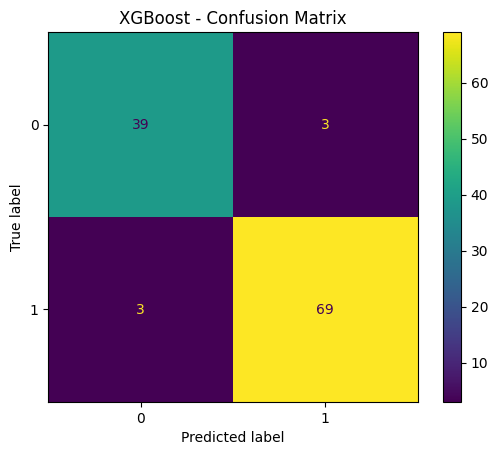

In [10]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"{best_name} - Confusion Matrix")
plt.show()

## 17. 看 ROC 曲線

這段和你原本講義前半段的 ROC / AUC 教學可以很好銜接。  
原講義先教 ROC 與 threshold，再進 ensemble；這份 notebook 也建議你保留這種學法，因為 **boosting 最後仍然是在做分類機率與排序問題**。fileciteturn0file0L9-L16

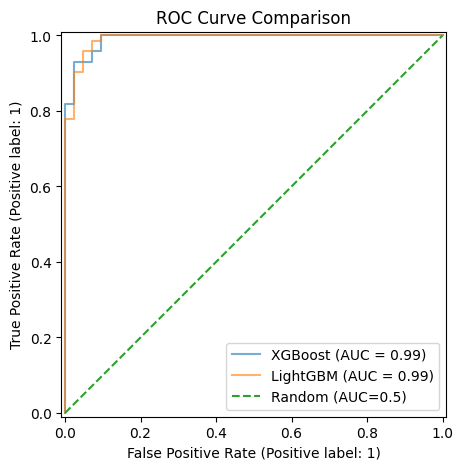

In [36]:
plt.figure(figsize=(7, 5))
ax=plt.gca()
xgb_clf_disp=RocCurveDisplay.from_estimator(xgb_clf, X_test, y_test, name="XGBoost", ax=ax, curve_kwargs={"alpha": 0.6})
lgbm_clf_disp=RocCurveDisplay.from_estimator(lgbm_clf, X_test, y_test, name="LightGBM", ax=ax, curve_kwargs={"alpha": 0.6})
plt.plot([0, 1], [0, 1], "--", label="Random (AUC=0.5)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 18. Feature importance

先提醒一件事：

**feature importance 可以看，但不要把它當成絕對真理。**

原因：
- 不同 importance 定義不一樣
- 高相關特徵會互相分攤重要性
- 它比較像「模型內部偏好」的線索，不一定等於因果

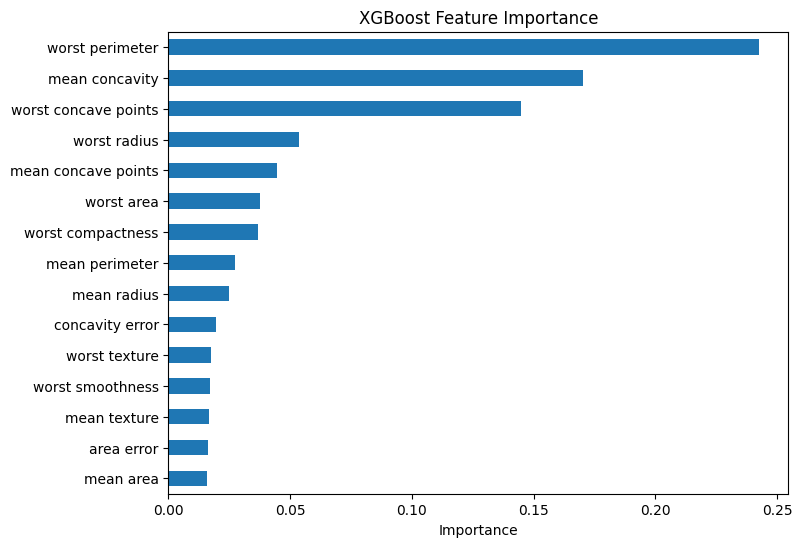

In [37]:
def plot_feature_importance(model, feature_names, top_n=15, title="Feature Importance"):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.show()

plot_feature_importance(xgb_clf, X.columns, top_n=15, title="XGBoost Feature Importance")

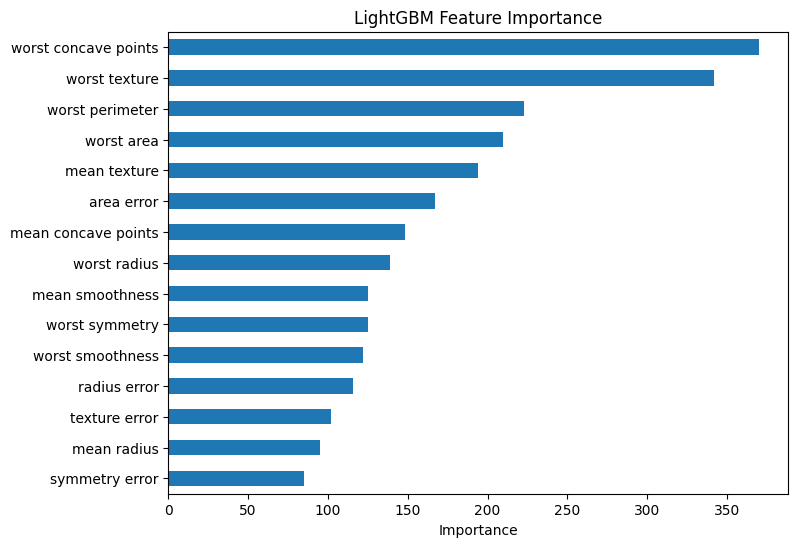

In [38]:
plot_feature_importance(lgbm_clf, X.columns, top_n=15, title="LightGBM Feature Importance")

## 19. Early Stopping：為什麼很重要？

Boosting 有一個很常見的風險：

- 樹加太多輪後
- training 表現繼續變好
- validation / test 卻開始退步

這就是很典型的過擬合。

### Early stopping 的想法
當 validation 分數連續幾輪都沒有進步，就提前停下來。

這比你硬猜 `n_estimators` 要更聰明。

### XGBoost / LightGBM 的 early stopping 備註

不同版本的 `xgboost`、`lightgbm` 與 sklearn wrapper，early stopping 的寫法可能略有差異。  
如果你本機版本和這份寫法不完全一致，不要慌，通常是版本 API 差異，不是你壞掉了，頂多是套件在耍個性。

下面先提供一個常見思路版本。

In [39]:
# 範例：若你的套件版本支援，可參考這種寫法
# 不同版本可能需要微調參數名稱

xgb_es = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=50
)

# eval_set 只會監控驗證集表現；
# 若要讓模型自動找出最佳迭代輪數，還需要設定 early_stopping_rounds。

xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

print("best_iteration:", getattr(xgb_es, "best_iteration", None))

best_iteration: 297


In [40]:
results = xgb_es.evals_result()
print(results.keys())
print(results["validation_0"]["logloss"][:5])

dict_keys(['validation_0'])
[0.6400928194062752, 0.6184909798597035, 0.5975177094601748, 0.5770697415920726, 0.5588788039851607]


## 20. 一個實務上很常見的調參方向

### 第一步：先固定一組保守 baseline
例如：

- `learning_rate=0.05`
- `n_estimators=200`
- `max_depth=3`

### 第二步：先處理過擬合問題
若 valid 比 train 差很多，可以試：

- 降低 `max_depth`
- 提高 `min_child_weight` / `min_child_samples`
- 降低 `num_leaves`
- 增加 `reg_alpha` / `reg_lambda`
- 使用 `subsample`, `colsample_bytree`

### 第三步：再微調 learning rate 與 estimators
- 小 learning rate + 多樹
- 搭配 early stopping

### 第四步：最後才做比較細的 search
例如：
- GridSearchCV
- RandomizedSearchCV
- Optuna

### 補充：XGBoost / LightGBM 通常不用 GridSearchCV

原因：

- 有 early stopping
- 有 validation set
- CV 不一定必要

GridSearchCV 採用固定的 cross-validation 流程，與 early stopping 需要動態 validation set 的機制衝突，因此在實務上通常會改用 ParameterGrid 搭配手動訓練流程來進行調參。

ParameterGrid 本身並不提供 early stopping，但因為使用者可以完全控制模型的 fit 流程，因此可以搭配 eval_set 與 early_stopping_rounds 自行實現 early stopping；而 GridSearchCV 將訓練流程封裝起來，導致難以整合這種動態訓練機制。

Early stopping 需要在同一個 validation set 上持續監控模型表現，才能公平比較不同迭代的效果，因此通常會使用固定的 validation set；若 validation 資料不一致，將無法判斷模型是否真正改善。

In [41]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
}

simple_results = []

for params in ParameterGrid(param_grid):
    model = XGBClassifier(
        n_estimators=200,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        **params
    )
    result = evaluate_classifier(
        model, X_train, y_train, X_valid, y_valid, X_test, y_test, name=str(params)
    )
    result.update(params)
    simple_results.append(result)

tuning_df = pd.DataFrame(simple_results).sort_values("valid_roc_auc", ascending=False)
tuning_df[["max_depth", "learning_rate", "subsample", "valid_roc_auc", "test_roc_auc"]].head(10).round(4)

,max_depth,learning_rate,subsample,valid_roc_auc,test_roc_auc
12,2,0.10,0.8,0.9931,0.9894
0,2,0.03,0.8,0.9928,0.9921
8,3,0.05,0.8,0.9928,0.9914
10,4,0.05,0.8,0.9928,0.9917
9,3,0.05,1.0,0.9921,0.9931
6,2,0.05,0.8,0.9918,0.9914
7,2,0.05,1.0,0.9918,0.9907
1,2,0.03,1.0,0.9918,0.9937
16,4,0.10,0.8,0.9918,0.9911
13,2,0.10,1.0,0.9915,0.9894


In [ ]:
# 已有 Baseline 及 設計參數組合後：

# from sklearn.model_selection import ParameterGrid

# best_score = float("inf")
# best_params = None

# for params in ParameterGrid(param_grid):
#     model = XGBClassifier(
#         **params,
#         n_estimators=1000,
#         eval_metric="logloss"
#     )

#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_valid, y_valid)],
#         early_stopping_rounds=50,
#         verbose=False
#     )

#     score = model.best_score

#     if score < best_score:
#         best_score = score
#         best_params = params

In [ ]:
# 記得透過最後得到的最佳參數重新訓練模型

# final_model = XGBClassifier(
#     **best_params,
#     n_estimators=model.best_iteration
# )

# final_model.fit(X_train_full, y_train_full)

## 21. 初學者最常見的誤區

### 誤區 1：把 boosting 當成「很多樹 = 一定更好」
不一定。  
樹太多、太深、learning rate 太大，都可能讓模型過擬合。

### 誤區 2：只看 accuracy
類別不平衡時，accuracy 可能很會騙人。

### 誤區 3：feature importance 很高 = 因果關係
不是。  
那只是模型在目前資料與目前訓練方式下的偏好。

### 誤區 4：LightGBM 比 XGBoost 快，所以一定比較好
快不等於一定更適合。  
你還是要看：
- 資料量
- 特徵型態
- 泛化表現
- 調參穩定度

### 誤區 5：套件跑得動就算理解了
真的理解應該至少能回答：

- 為什麼 boosting 是 sequential？
- 為什麼 learning rate 要和 n_estimators 一起看？
- 為什麼 XGBoost / LightGBM 比 AdaBoost 更現代？
- 為什麼 LightGBM 比較需要注意樹長太快？

## 22. 你可以怎麼把這份內容接到前面學過的 Random Forest？

這是一個很好的學習順序：

1. **Decision Tree**
   - 先懂樹怎麼切
   - 懂 overfitting 為什麼容易發生

2. **Random Forest**
   - 理解 bagging
   - 理解 bootstrap 與投票
   - 理解降低 variance

3. **Gradient Boosting**
   - 理解 sequential 修正錯誤
   - 理解 bias 的改善
   - 理解 learning rate / stage-wise additivity

4. **XGBoost / LightGBM**
   - 理解現代 boosting 的工程強化
   - 開始練實務調參

如果你前面已經學過 Random Forest，現在進 XGBoost / LightGBM 其實很順，因為兩邊的 base learner 都常是 tree，只是組合方式不同。

## 23. 面試或報告時可以怎麼講？

### 一段簡潔版本
> Random Forest 屬於 bagging，重點是透過 bootstrap 與多棵樹投票來降低 variance；  
> XGBoost 與 LightGBM 則屬於 gradient boosting，會一輪一輪修正前面模型的錯誤，通常更擅長降低 bias。  
> 在實務上，我會用 validation、ROC-AUC、F1、early stopping 與參數控制來避免 boosting 過擬合。

### 再進一步一點
> XGBoost 強調正則化與穩健的最佳化，LightGBM 則更強調速度與大資料效率。  
> 若資料量大、訓練速度重要，我會優先測試 LightGBM；若希望有較成熟穩定的起手式，我通常也會測 XGBoost 做比較。

## 24. 最後總整理

### 一句話版
- **Random Forest**：很多樹各自投票，像一群人獨立判斷後表決
- **XGBoost / LightGBM**：不是各玩各的，而是一個接一個補洞

### 核心差異
- Bagging 主要降 variance
- Boosting 主要降 bias
- XGBoost / LightGBM 都是現代 GBDT 實作

### 🔥 Boosting 模型（XGBoost / LightGBM）調參邏輯

**Boosting 的調參通常會先透過 baseline 建立對模型行為的直覺，  
再利用 ParameterGrid 搭配 early stopping 進行搜尋，  
最終選出最佳 hyperparameters 並重新訓練模型。**

Boosting 模型在訓練過程中會逐步建立多棵樹，每一輪都在修正前一輪的錯誤，  
因此模型的最佳狀態通常是在訓練過程中產生，而非訓練完成後再挑選。

為了在訓練過程中找到最佳模型，會使用 early stopping 機制，  
透過固定的 validation set 持續監控模型表現，並在表現不再提升時停止訓練。

這與傳統如 Random Forest 的做法不同：

- 傳統模型：透過 cross-validation（如 GridSearchCV）評估不同參數
- Boosting 模型：透過 hold-out validation + early stopping 動態決定最佳 iteration

在實務上，Boosting 的調參流程通常為：

1. 使用 ParameterGrid 產生不同的 hyperparameter 組合
2. 對每組參數：
   - 使用固定 validation set 訓練模型
   - 搭配 early stopping 找到最佳 iteration
3. 比較 validation 表現，選出最佳參數

因此：

- ParameterGrid 提供參數組合
- early stopping 負責找最佳模型複雜度
- validation set 提供一致的評估標準

三者共同構成 Boosting 模型的核心調參流程。

### 調參最常抓的旋鈕
- `learning_rate`
- `n_estimators`
- `max_depth`
- `num_leaves`（LightGBM）
- `subsample`
- `colsample_bytree`
- 正則化參數
- early stopping

### 學習建議
先把：
- boosting 的直覺
- gradient boosting 的流程
- XGBoost / LightGBM 差異
- 過擬合控制方法

這四件事搞懂，比死背參數表更重要。

## 25. 練習題

1. 為什麼 boosting 不能像 random forest 那樣完全平行理解？
2. 為什麼 `learning_rate` 變小時，通常要搭配更多棵樹？
3. 為什麼 LightGBM 的 `num_leaves` 很重要？
4. 如果 train 分數很高、valid 分數掉很多，你會先調哪些參數？
5. 在類別不平衡問題中，為什麼不能只看 accuracy？

1. Boosting 是序列式（sequential）訓練，每一輪模型都依賴前一輪的錯誤（residual 或 gradient），因此無法平行；而 Random Forest 採用 bagging，每棵樹彼此獨立，可以平行訓練後再進行投票。
2. learning_rate 變小代表每一棵樹對模型的影響變小，因此需要更多棵樹來累積效果，才能達到相同的擬合能力。
3. LightGBM 採用 leaf-wise 成長策略，若不限制 num_leaves，模型會優先分裂最有利的節點，可能導致樹變得非常深且不平衡，容易過擬合，因此 num_leaves 是控制模型複雜度的核心參數。
4. 這通常代表 overfitting，可以透過以下方式控制模型複雜度：

- 降低 max_depth（限制樹深）
- 減少 num_leaves（LightGBM）
- 增加 min_child_weight / min_data_in_leaf
- 使用 subsample / colsample_bytree 增加隨機性
- 增加 regularization（lambda / alpha）
- 降低 learning_rate 並搭配更多樹
  
5. 在類別不平衡問題中，accuracy 可能具有誤導性，例如模型只預測多數類別就能得到高 accuracy，但對少數類別完全沒有辨識能力，因此需要搭配 precision、recall、F1-score 或 confusion matrix 來評估模型在不同類別上的表現。

### Boosting vs Bagging
Boosting 為序列式學習，每一輪依賴前一輪的錯誤，因此無法平行；Bagging 則為獨立訓練，可平行處理。

### Learning Rate
learning_rate 控制每一步更新幅度，當 learning_rate 變小時，需要更多樹來累積模型能力。

### LightGBM num_leaves
num_leaves 控制 leaf-wise 樹的複雜度，避免樹過深與過擬合。

### Overfitting 處理
透過限制樹深、葉節點數、增加正則化與隨機性來控制模型複雜度。

### 不平衡資料評估
accuracy 可能誤導，需要搭配 precision、recall、F1-score 等指標。